In [5]:
import os
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
project_path = "/content/drive/MyDrive/checkered_fabric_detector"
os.chdir(project_path)

print(os.getcwd())

/content/drive/MyDrive/checkered_fabric_detector


In [9]:
import torch
from torchvision import datasets, transforms

dataset_path = "dataset"

In [10]:
#Make Images ready to be fed to the NN model

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

Total images: 150
Classes: ['Circle', 'Line', 'No defect']


**Create 5 Fold Splits
Train 5 times with average results**

In [11]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

labels = [label for _, label in dataset]
# print(labels)
# print(len(labels))

#randomly mixing data before splitting & fixing randomness
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = list(skf.split(np.zeros(len(labels)), labels))

print("Number of folds:", len(folds))

for i, (train_idx, test_idx) in enumerate(folds):
    print(f"Fold {i+1}: train={len(train_idx)}, test={len(test_idx)}")

Number of folds: 5
Fold 1: train=120, test=30
Fold 2: train=120, test=30
Fold 3: train=120, test=30
Fold 4: train=120, test=30
Fold 5: train=120, test=30


**Create Dataloaders with augmentation**

In [12]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

#To prevent from overfitting
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

#Reload dataset with transforms
train_dataset_full = datasets.ImageFolder(dataset_path, transform=train_tf)
test_dataset_full  = datasets.ImageFolder(dataset_path, transform=test_tf)


# -------- Use ONLY first fold for now --------
train_idx, test_idx = folds[0]

train_subset = Subset(train_dataset_full, train_idx)
test_subset  = Subset(test_dataset_full, test_idx)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_subset, batch_size=16)


print("Train size:", len(train_subset))
print("Test size:", len(test_subset))

Train size: 120
Test size: 30


**Load ResNet18 model ==> First training run(ResNet-18 is the goto model when working with smaller datasets or constrained computational environments)**

In [13]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

#Load pretrained ResNet18
model = models.resnet18(pretrained=True)

#Freeze all layers
for param in model.parameters():
    param.requires_grad = False

#Replace final layer for the 3 classes
model.fc = nn.Linear(model.fc.in_features, 3)

model = model.to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


#Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)  #Only final layer


#Training loop

epochs = 8

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")


#Evaluate on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# -----------------
# Metrics
# -----------------
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Epoch 1/8, Loss: 1.1171
Epoch 2/8, Loss: 0.9246
Epoch 3/8, Loss: 0.8559
Epoch 4/8, Loss: 0.6853
Epoch 5/8, Loss: 0.6335
Epoch 6/8, Loss: 0.5567
Epoch 7/8, Loss: 0.5242
Epoch 8/8, Loss: 0.4858
Classification Report:
              precision    recall  f1-score   support

      Circle       1.00      0.90      0.95        10
        Line       1.00      1.00      1.00        10
   No defect       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[ 9  0  1]
 [ 0 10  0]
 [ 0  0 10]]


In [15]:
from torch.utils.data import Subset
import copy

num_folds = 5
fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(folds):
    print(f"\n--- Fold {fold+1} ---")

    #Prepare subsets
    train_subset = Subset(train_dataset_full, train_idx)
    test_subset  = Subset(test_dataset_full, test_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_subset, batch_size=16)

    #Load fresh model for each fold
    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 3)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

    #Training
    epochs = 8
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

    #Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    #Compute accuracy
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")


#Final results

avg_acc = np.mean(fold_accuracies)
print(f"\nAverage Accuracy over {num_folds} folds: {avg_acc:.4f}")


--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/8, Loss: 1.1714
Epoch 2/8, Loss: 1.0054
Epoch 3/8, Loss: 0.8121
Epoch 4/8, Loss: 0.7034
Epoch 5/8, Loss: 0.6976
Epoch 6/8, Loss: 0.5888
Epoch 7/8, Loss: 0.5825
Epoch 8/8, Loss: 0.5005
Fold 1 Accuracy: 0.8667

--- Fold 2 ---
Epoch 1/8, Loss: 1.1366
Epoch 2/8, Loss: 1.0338
Epoch 3/8, Loss: 0.8467
Epoch 4/8, Loss: 0.7618
Epoch 5/8, Loss: 0.7477
Epoch 6/8, Loss: 0.6690
Epoch 7/8, Loss: 0.5422
Epoch 8/8, Loss: 0.5863
Fold 2 Accuracy: 1.0000

--- Fold 3 ---
Epoch 1/8, Loss: 1.1172
Epoch 2/8, Loss: 0.9653
Epoch 3/8, Loss: 0.8496
Epoch 4/8, Loss: 0.7722
Epoch 5/8, Loss: 0.6775
Epoch 6/8, Loss: 0.6080
Epoch 7/8, Loss: 0.5411
Epoch 8/8, Loss: 0.4732
Fold 3 Accuracy: 1.0000

--- Fold 4 ---
Epoch 1/8, Loss: 1.1520
Epoch 2/8, Loss: 1.0332
Epoch 3/8, Loss: 0.8802
Epoch 4/8, Loss: 0.7513
Epoch 5/8, Loss: 0.7324
Epoch 6/8, Loss: 0.7080
Epoch 7/8, Loss: 0.6211
Epoch 8/8, Loss: 0.5036
Fold 4 Accuracy: 0.8333

--- Fold 5 ---
Epoch 1/8, Loss: 1.0813
Epoch 2/8, Loss: 0.9187
Epoch 3/8, Loss: 0.8400


Confusion Matrix & Sample Predictions

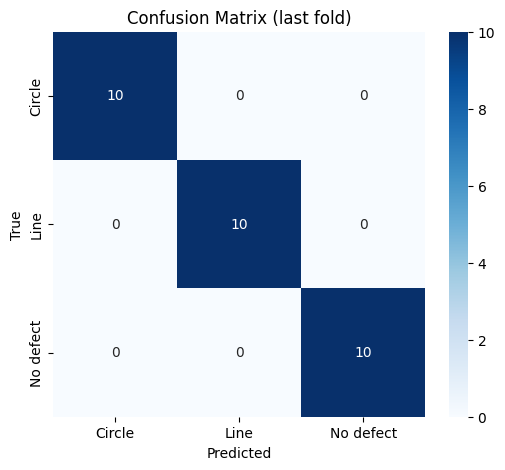

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Using the last fold predictions (or you can repeat for each fold)
cm = confusion_matrix(all_labels, all_preds)
classes = dataset.classes

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (last fold)")
plt.show()

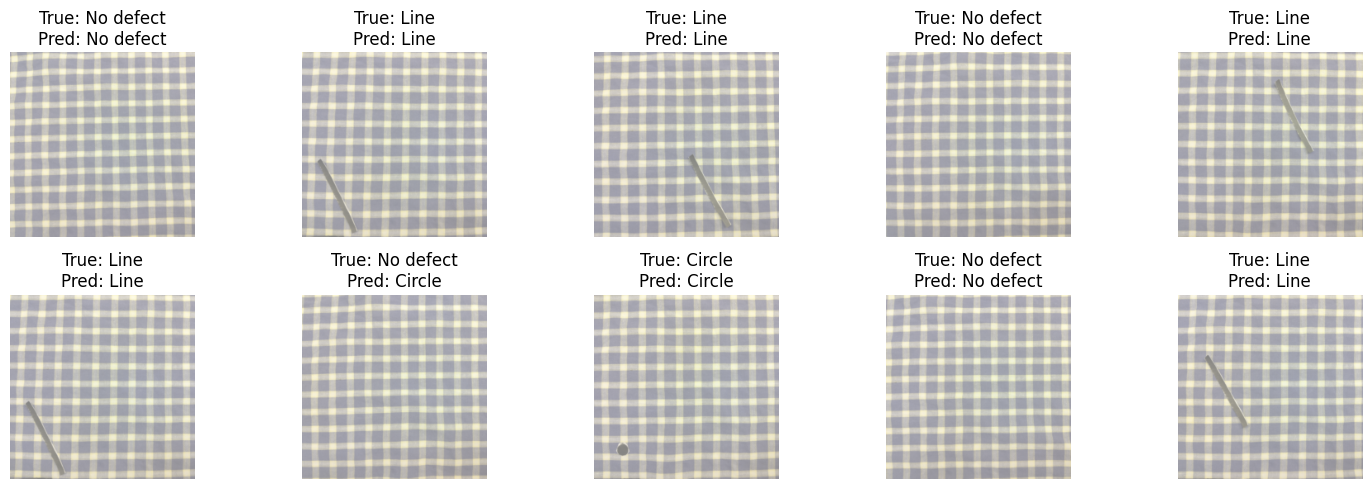

In [23]:
import torch
import matplotlib.pyplot as plt
import random

model.eval()

#Pick 10 random indices from the test dataset
test_indices = list(range(len(test_dataset_full)))
random.shuffle(test_indices)
sample_indices = test_indices[:10]

plt.figure(figsize=(15,5))
for i, idx in enumerate(sample_indices):
    img, label = test_dataset_full[idx]
    img_input = img.unsqueeze(0).to(device)  #Add batch dimension
    output = model(img_input)
    pred = output.argmax(1).item()

    #Denormalize for display
    img_show = img.permute(1,2,0) * 0.5 + 0.5

    plt.subplot(2,5,i+1)
    plt.imshow(img_show)
    plt.title(f"True: {dataset.classes[label]}\nPred: {dataset.classes[pred]}")
    plt.axis('off')

plt.tight_layout()
plt.show()